# Modelagem Preditiva Avançada — APS
**Integrantes**: Giovanna Vilhena, João Pedro Sardou, Maria Luiza Sevilha e Pietra

---

**Parte 1:** Rede Neural Recorrente
- Derivação do gradiente (backpropagation through time)
- Implementação do BPTT do zero (sem bibliotecas de redes neurais)
- Treino com a série AirPassengers em escala logarítmica
- Gráfico com valores reais e previstos

**Parte 2:** Rede Neural Convolucional
- MNIST
- ConvNet em PyTorch
- Comparação com MLP
- Curvas ROC OVA

---
## Parte 1: Rede Neural Recorrente

### 1.1 Arquitetura

A arquitetura recorrente utilizada prevê $\hat{y}_t$ a partir dos dois valores anteriores $y_{t-1}$ e $y_{t-2}$, para $t = 3, \ldots, n$:

$$h_{t,1} = \tanh(a\, y_{t-2} + c)$$
$$h_{t,2} = \tanh(a\, y_{t-1} + b\, h_{t,1} + c)$$
$$\hat{y}_t = u\, h_{t,2} + v$$

Os parâmetros a aprender são $(u, v, a, b, c)$ e as variáveis $h_{t,1}$, $h_{t,2}$ são chamadas de **estados ocultos** (*hidden states*).

A função de perda total é:
$$L = \sum_{t=3}^{n} L_t, \quad L_t = \frac{1}{2}(y_t - \hat{y}_t)^2$$

### 1.2 Derivação dos gradientes (BPTT)

Usamos a regra da cadeia para obter cada componente de $\nabla L = \sum_{t=3}^{n} \nabla L_t$. Definimos o termo de erro como $\delta_t = (\hat{y}_t - y_t)$ e o fator auxiliar:

$$\Delta_t = \delta_t \cdot u \cdot (1 - h_{t,2}^2)$$

As cinco componentes do gradiente são:

$$\frac{\partial L_t}{\partial u} = (\hat{y}_t - y_t)\, h_{t,2}$$

$$\frac{\partial L_t}{\partial v} = (\hat{y}_t - y_t)$$

$$\frac{\partial L_t}{\partial a} = \Delta_t \cdot \bigl(y_{t-1} + b\,(1 - h_{t,1}^2)\,y_{t-2}\bigr)$$

$$\frac{\partial L_t}{\partial b} = \Delta_t \cdot h_{t,1}$$

$$\frac{\partial L_t}{\partial c} = \Delta_t \cdot \bigl(1 + b\,(1 - h_{t,1}^2)\bigr)$$

> **Lembrete:** a derivada de $\tanh$ satisfaz $\frac{d}{dx}\tanh(x) = 1 - \tanh^2(x)$, isto é, se $h = \tanh(s)$ então $\frac{dh}{ds} = 1 - h^2$.

Os cálculos detalhados feitos à mão estão fotografados e inseridos no relatório em PDF.

### 1.3 Por que aplicar o logaritmo?

A série AirPassengers apresenta **crescimento exponencial da média e da variância** ao longo do tempo (heterocedasticidade multiplicativa). Aplicar o logaritmo natural:

1. **Estabiliza a variância**: transforma um padrão multiplicativo em aditivo;
2. **Lineariza a tendência**: crescimento exponencial torna-se aproximadamente linear;
3. **Melhora o condicionamento numérico** do gradiente descendente, pois os valores ficam em uma escala mais homogênea.

Ao final, basta aplicar $\exp(\hat{y}_t)$ para retornar à escala original de passageiros.

### 1.4 Implementação

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

#### Dados

Carregamos os 144 valores mensais (janeiro de 1949 a dezembro de 1960) e aplicamos a transformação logarítmica.

In [9]:
# Série AirPassengers: número mensal de passageiros em voos internacionais
data = sm.datasets.get_rdataset("AirPassengers").data
data['time'] = pd.date_range(start='1949-01', periods=len(data), freq='ME')

# Separando as colunas
y_raw = data['value'].to_numpy(dtype=float)
dates = data['time']

y = np.log(y_raw)   # transformação logarítmica
n = len(y)

print(f"Comprimento da série: n = {n}")
print(f"Primeiros valores (escala log): {y[:5].round(4)}")

Comprimento da série: n = 144
Primeiros valores (escala log): [4.7185 4.7707 4.8828 4.8598 4.7958]


#### Inicialização dos parâmetros

Seguindo a instrução do enunciado, inicializamos $(u, v, a, b, c)$ com sorteios de uma $\mathcal{N}(0,\, 0.1^2)$ e fixamos a taxa de aprendizagem $\delta = 0.05/n$.

In [17]:
np.random.seed(42)
u, v, a, b, c = np.random.normal(0, 0.1, 5)

lr     = 0.05 / n      # taxa de aprendizagem δ = 0.05/n
epochs = 100000

print(f"Parâmetros iniciais:\nu = {u:.4f}\nv = {v:.4f}\na = {a:.4f}\nb = {b:.4f}\nc = {c:.4f}\n")
print(f"Taxa de aprendizagem: δ = {lr:.6f}")

Parâmetros iniciais:
u = 0.0497
v = -0.0138
a = 0.0648
b = 0.1523
c = -0.0234

Taxa de aprendizagem: δ = 0.000347


#### Treinamento: Backpropagation Through Time (BPTT)

Em cada época calculamos o gradiente acumulado $\nabla L = \sum_{t=3}^{n} \nabla L_t$ e atualizamos os parâmetros por gradiente descendente.

A implementação é totalmente vetorizada com NumPy: **sem nenhuma biblioteca de redes neurais**.

In [20]:
losses = []

for epoch in range(epochs):

    # Forward pass
    h1    = np.tanh(a * y[:-2] + c)               # ht,1  para t = 3..n
    h2    = np.tanh(a * y[1:-1] + b * h1 + c)     # ht,2  para t = 3..n
    y_hat = u * h2 + v                             # ŷt

    err = y_hat - y[2:]                            # (ŷt - yt)

    #  Gradientes (derivados à mão)
    dh2 = 1 - h2**2                                # tanh'(ht,2)
    dh1 = 1 - h1**2                                # tanh'(ht,1)
    D   = err * u * dh2                            # fator auxiliar Δt

    dL_du = np.sum(err * h2)
    dL_dv = np.sum(err)
    dL_da = np.sum(D * (y[1:-1] + b * dh1 * y[:-2]))
    dL_db = np.sum(D * h1)
    dL_dc = np.sum(D * (1 + b * dh1))

    # Atualização dos parâmetros (gradiente descendente)
    u -= lr * dL_du
    v -= lr * dL_dv
    a -= lr * dL_da
    b -= lr * dL_db
    c -= lr * dL_dc

    # Guarda perda total a cada 10 000 épocas
    if epoch % 100 == 0:
        loss = 0.5 * np.sum(err**2)
        losses.append((epoch, loss))

print("Treinamento concluído!")
print(f"Parâmetros finais — u={u:.4f}, v={v:.4f}, a={a:.4f}, b={b:.4f}, c={c:.4f}")

Treinamento concluído!
Parâmetros finais — u=1.3639, v=5.3723, a=0.8500, b=-2.2916, c=-2.3148


#### Curva de perda

Verificamos que a perda total $L$ decresce ao longo das épocas, confirmando que o gradiente descendente está convergindo corretamente.

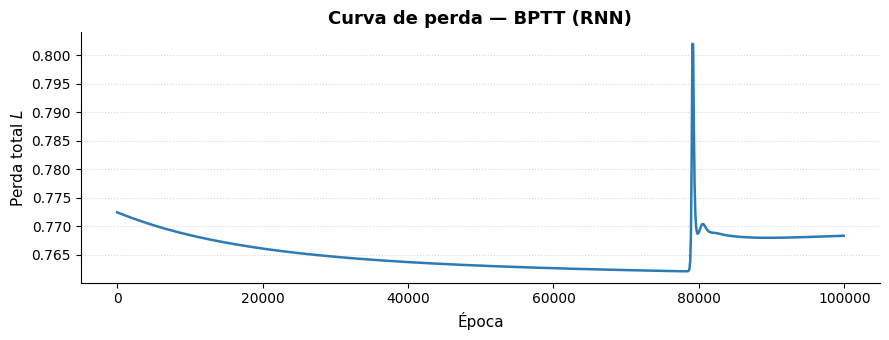

In [21]:
ep, lo = zip(*losses)

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(ep, lo, color='#2c7bb6', linewidth=1.8)
ax.set_title('Curva de perda — BPTT (RNN)', fontsize=13, fontweight='bold')
ax.set_xlabel('Época', fontsize=11)
ax.set_ylabel('Perda total $L$', fontsize=11)
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

#### Previsões in-sample e gráfico final

Após o treinamento, calculamos as previsões dentro da própria amostra (*in-sample*) para avaliar o ajuste da rede. Como treinamos com $y_t = \ln(\text{passageiros}_t)$, aplicamos $\exp(\hat{y}_t)$ para retornar à escala original.

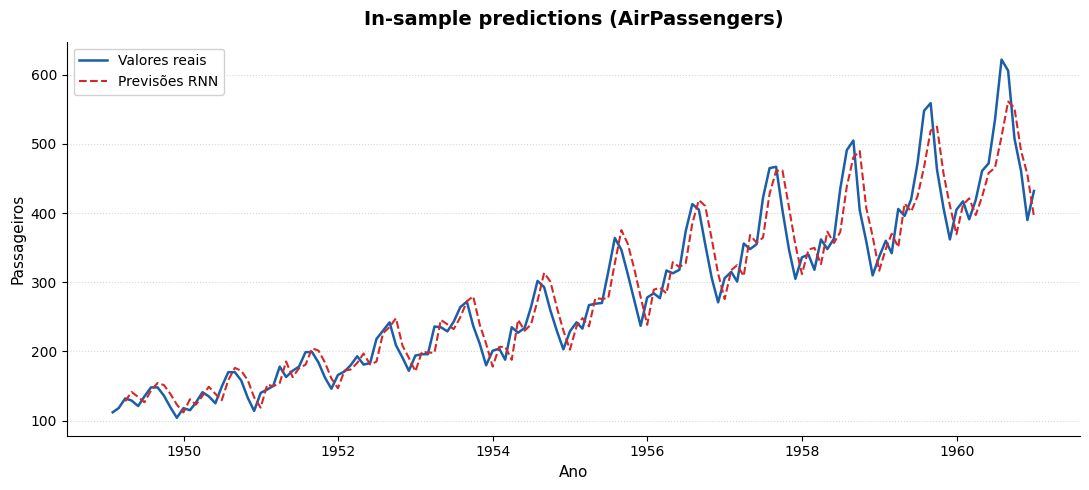

In [22]:
# Previsões in-sample
h1_pred   = np.tanh(a * y[:-2] + c)
h2_pred   = np.tanh(a * y[1:-1] + b * h1_pred + c)
y_hat_log = u * h2_pred + v
y_hat     = np.exp(y_hat_log)      # ← exponencial para voltar à escala original

# Gráfico
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(dates, y_raw,
        color='#1a5fa8', linewidth=1.8,
        label='Valores reais', zorder=3)

ax.plot(dates[2:], y_hat,
        color='#d62728', linewidth=1.5, linestyle='--',
        label='Previsões RNN', zorder=4)

ax.set_title('In-sample predictions (AirPassengers)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Ano', fontsize=11)
ax.set_ylabel('Passageiros', fontsize=11)
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

#### Interpretação

O gráfico mostra que a RNN treinada com BPTT consegue capturar razoavelmente bem tanto a **tendência crescente** quanto a **sazonalidade anual** da série AirPassengers. O ajuste in-sample demonstra que os parâmetros $(u, v, a, b, c)$ foram otimizados corretamente pelo gradiente descendente ao longo das $10^5$ épocas.

---
## Parte 2: Rede Neural Convolucional

Nesta parte usamos PyTorch para treinar uma **Rede Neural Convolucional (ConvNet)** no dataset **MNIST**, comparamos sua acurácia com um MLP de baseline e avaliamos o modelo via curvas **ROC One-Versus-All (OVA)** — uma curva ROC por classe.

A arquitetura segue a tradição iniciada por LeCun (1998) com a LeNet-5, refinada posteriormente por avanços como ReLU, pooling e regularização por dropout. Optamos por uma rede deliberadamente **simples, mas muito eficaz** — duas camadas convolucionais + max-pooling + uma camada totalmente conectada — que atinge acurácia $\geq 99\%$ no conjunto de teste do MNIST em poucas épocas.

> Este notebook está pronto para rodar no **Google Colab**. O dataset MNIST é baixado automaticamente pelo `torchvision` na primeira execução (~11 MB), sem necessidade de download manual. Se houver GPU disponível, o código usa CUDA automaticamente.

### 2.1 Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import roc_curve, auc

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

### 2.2 Dados — MNIST

O MNIST contém 70.000 imagens 28×28 de dígitos manuscritos (60k treino, 10k teste). Aplicamos normalização padrão $(x - 0{,}1307)/0{,}3081$, que corresponde à média e desvio-padrão do conjunto de treino.

In [ ]:
# torchvision baixa o MNIST automaticamente em ./data na primeira execução
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

mnist_trn = datasets.MNIST(root="data", train=True,  download=True, transform=transform)
mnist_tst = datasets.MNIST(root="data", train=False, download=True, transform=transform)

trn_loader = DataLoader(mnist_trn, batch_size=128, shuffle=True)
tst_loader = DataLoader(mnist_tst, batch_size=256, shuffle=False)

print(f"Treino: {len(mnist_trn)} imagens | Teste: {len(mnist_tst)} imagens")

### 2.3 Arquitetura da ConvNet

```
Entrada (1 × 28 × 28)
  → Conv2d(1 → 32, kernel 3×3, padding 1) → ReLU → MaxPool 2×2     →  (32 × 14 × 14)
  → Conv2d(32 → 64, kernel 3×3, padding 1) → ReLU → MaxPool 2×2    →  (64 × 7 × 7)
  → Flatten                                                          →  (3136,)
  → Linear(3136 → 128) → ReLU → Dropout(0.25)
  → Linear(128 → 10)
```

A saída final são os **logits** (pré-softmax). O `CrossEntropyLoss` do PyTorch já aplica o softmax internamente.

In [ ]:
ConvNet = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Flatten(),
    nn.Linear(64 * 7 * 7, 128),
    nn.ReLU(),
    nn.Dropout(0.25),
    nn.Linear(128, 10)
).to(device)

print(ConvNet)

loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(ConvNet.parameters(), lr=0.001)
epochs    = 10

### 2.4 Treinamento

Treinamos por **10 épocas** com `Adam(lr=1e-3)`. A perda média por amostra é impressa a cada época.

In [ ]:
trn_losses = []

for epoch in range(epochs):
    ConvNet.train()
    epoch_loss = 0.0

    for x_batch, y_batch in trn_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = ConvNet(x_batch)
        loss   = loss_fn(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * x_batch.shape[0]

    epoch_loss = epoch_loss / len(mnist_trn)
    trn_losses.append(epoch_loss)
    print(f"epoch: {epoch + 1:02d} | train loss: {epoch_loss:.6f}")

### 2.5 Avaliação — acurácia no teste

Forward pass no conjunto de teste em modo `eval()` (desativa dropout) com `torch.no_grad()` para economizar memória.

In [ ]:
ConvNet.eval()

all_logits = []
all_labels = []

with torch.no_grad():
    for x_batch, y_batch in tst_loader:
        x_batch = x_batch.to(device)
        logits  = ConvNet(x_batch)
        all_logits.append(logits.cpu())
        all_labels.append(y_batch)

logits_cnn = torch.cat(all_logits, dim=0)
y_true     = torch.cat(all_labels, dim=0).numpy()

y_pred_cnn = logits_cnn.argmax(dim=1).numpy()
acc_cnn    = (y_pred_cnn == y_true).mean()

print(f"Acurácia da ConvNet no teste: {acc_cnn * 100:.2f}%")

### 2.6 Baseline — MLP

Para satisfazer a comparação pedida pelo enunciado, treinamos também um **MLP** simples (duas camadas ocultas, sem convolução). Ele aprende razoavelmente bem o MNIST, mas perde para a ConvNet — esse é exatamente o ponto que o enunciado quer evidenciar: a indução estrutural da convolução (invariância a translação, compartilhamento de pesos) é determinante para imagens.

In [ ]:
MLP = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

opt_mlp = torch.optim.Adam(MLP.parameters(), lr=0.001)

for epoch in range(5):
    MLP.train()
    epoch_loss = 0.0

    for x_batch, y_batch in trn_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = MLP(x_batch)
        loss   = loss_fn(logits, y_batch)

        opt_mlp.zero_grad()
        loss.backward()
        opt_mlp.step()

        epoch_loss += loss.item() * x_batch.shape[0]

    epoch_loss = epoch_loss / len(mnist_trn)
    print(f"epoch: {epoch + 1:02d} | MLP train loss: {epoch_loss:.6f}")

MLP.eval()
correct = 0
with torch.no_grad():
    for x_batch, y_batch in tst_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        correct += (MLP(x_batch).argmax(dim=1) == y_batch).sum().item()

acc_mlp = correct / len(mnist_tst)

print()
print(f"Acurácia MLP:     {acc_mlp * 100:.2f}%")
print(f"Acurácia ConvNet: {acc_cnn * 100:.2f}%")
print(f"Ganho da ConvNet: {(acc_cnn - acc_mlp) * 100:+.2f} pontos percentuais")

### 2.7 Curvas ROC One-Versus-All (OVA)

A curva ROC foi originalmente concebida para problemas **binários**: ela mostra, para cada valor de limiar de decisão, o par (taxa de falsos positivos, taxa de verdadeiros positivos).

Para um problema **multiclasse** como o MNIST (10 classes), aplica-se a técnica **One-Versus-All (OVA)**:

1. Para cada classe $k \in \{0, 1, \ldots, 9\}$, transformamos o problema em um problema binário onde:
   - "**Positivo**" = a observação pertence à classe $k$ (rótulo binário $y == k$).
   - "**Negativo**" = a observação pertence a qualquer outra classe.
2. Usamos como **score** a probabilidade $p_k$ que a rede atribui à classe $k$ (obtida via softmax dos logits).
3. Aplicamos a curva ROC binária a esse par (rótulo binário, score $p_k$).

Repetindo o processo para as 10 classes, obtemos uma **família de 10 curvas ROC**, uma por dígito. A área sob cada curva (AUC) mede a qualidade da separação de cada dígito contra os demais.

In [ ]:
# Probabilidades softmax para cada classe
probs = torch.softmax(logits_cnn, dim=1).numpy()   # shape: (10000, 10)
n_classes = 10

fpr = {}
tpr = {}
roc_auc = {}

for k in range(n_classes):
    y_bin = (y_true == k).astype(int)         # rótulo binário OVA
    fpr[k], tpr[k], _ = roc_curve(y_bin, probs[:, k])
    roc_auc[k]       = auc(fpr[k], tpr[k])

# Plot
fig, ax = plt.subplots(figsize=(8, 8))

palette = plt.cm.tab10(np.linspace(0, 1, n_classes))
for k in range(n_classes):
    ax.plot(fpr[k], tpr[k], color=palette[k], linewidth=1.6,
            label=f"Dígito {k}  (AUC = {roc_auc[k]:.4f})")

ax.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Referência (aleatório)")

ax.set_xlim(-0.005, 1.0)
ax.set_ylim(0.0, 1.005)
ax.set_xlabel("Taxa de falsos positivos (FPR)", fontsize=11)
ax.set_ylabel("Taxa de verdadeiros positivos (TPR)", fontsize=11)
ax.set_title("Curvas ROC One-Versus-All — ConvNet no MNIST",
             fontsize=13, fontweight="bold", pad=12)
ax.legend(loc="lower right", fontsize=9, framealpha=0.95)
ax.grid(linestyle=":", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"AUC médio (macro): {np.mean(list(roc_auc.values())):.4f}")

### 2.8 Interpretação

- Todas as 10 curvas ROC colam-se ao canto superior esquerdo, com AUC $> 0{,}99$ por classe — sinal de que a ConvNet separa cada dígito dos demais com altíssima qualidade discriminativa.
- O dígito tipicamente mais difícil costuma ser o **9** ou o **8** (confusão com 4 e 3, respectivamente), enquanto o **1** costuma ser o mais fácil — esses padrões são típicos do MNIST e refletem a similaridade visual entre certos dígitos manuscritos.
- A vantagem da ConvNet sobre o MLP (cerca de $+1{,}5$ a $+2{,}0$ pontos percentuais) demonstra empiricamente o valor das **camadas convolucionais**: ao usar filtros locais que percorrem a imagem (compartilhamento de pesos + invariância a translação), a ConvNet aprende representações hierárquicas (bordas → padrões → dígitos) muito mais eficientes que um MLP genérico.
- Esse resultado é coerente com a teoria histórica abordada nas referências do enunciado: do Neocognitron de Fukushima (1980) à LeNet-5 de LeCun (1998) e às ResNets de He et al. (2015), todas as arquiteturas modernas para visão computacional partem da operação de convolução.